In [3]:
from env import config, environment, loghelper
from methods import RandomScaling, ConstantScaling, GDCScaling
from methods import Predicter


class TrainAndTestHelper(object):
    def __init__(self, env: environment.DataCenterEnvironment, agent: RandomScaling.RandomScalingAgent, logger: loghelper.LogHelper):
        self.env = env
        self.agent = agent
        self.logger = logger

    def test(self):
        total_reward = 0
        done = False
        state, _ = self.env.reset()

        while(not done):
            ob = self.env.update_requests()
            action = self.agent.get_action(ob)
            next_state, reward, done, _, info = self.env.step(action)
            if info["t_exe"] > 100:
                t_total_list, t_exe_list, t_route_list = self.env.cal_total_access_delay(self.env.state["deploy_info"])
                pass
            total_reward += reward
            for key in info:
                self.logger.record(key, info[key])

        print("total_reward: ", total_reward)
        self.logger.visualize()

total_reward:  8645.46675168044


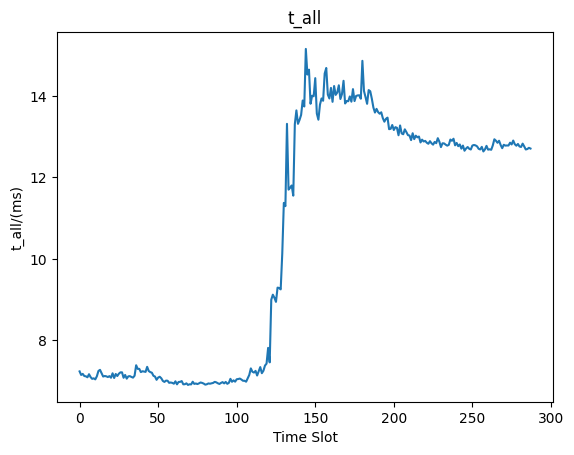

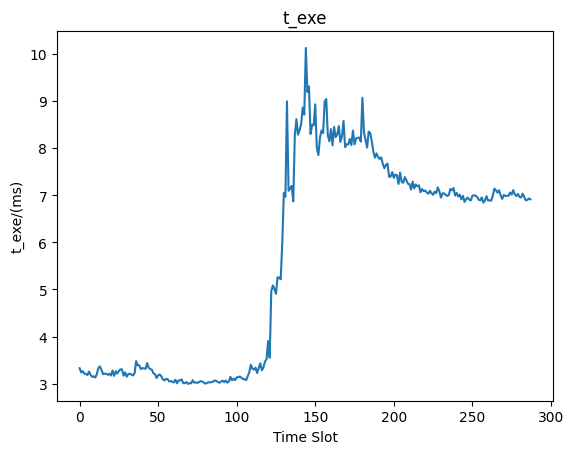

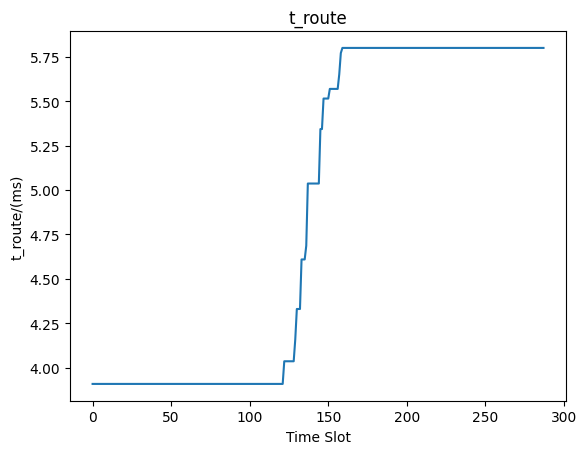

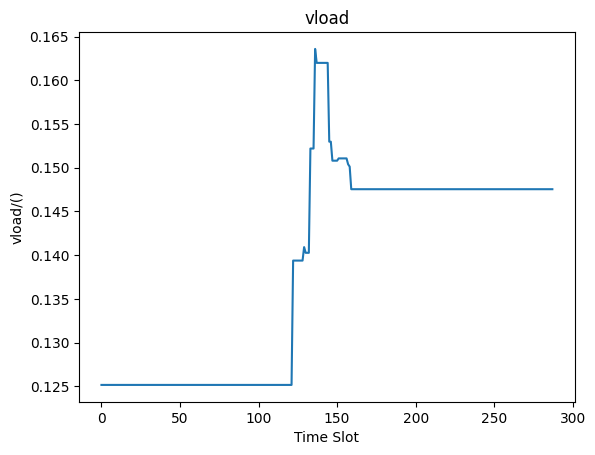

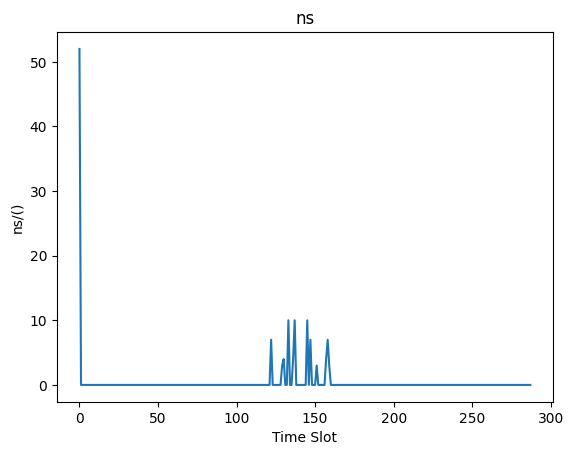

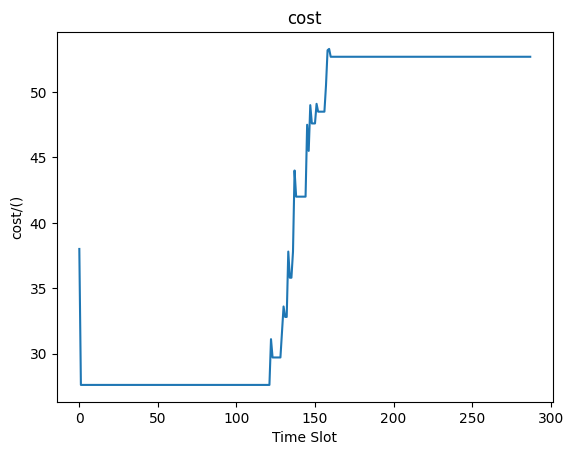

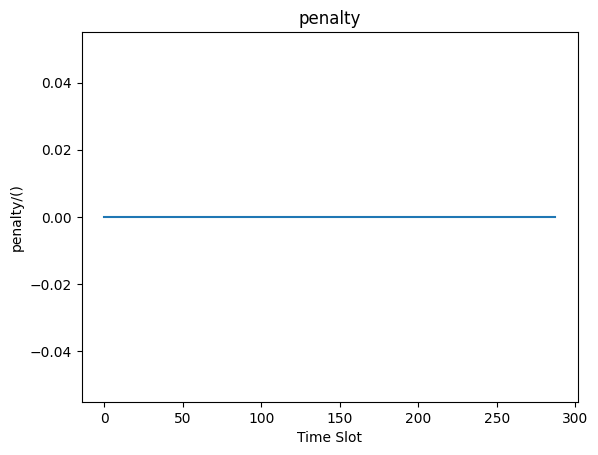

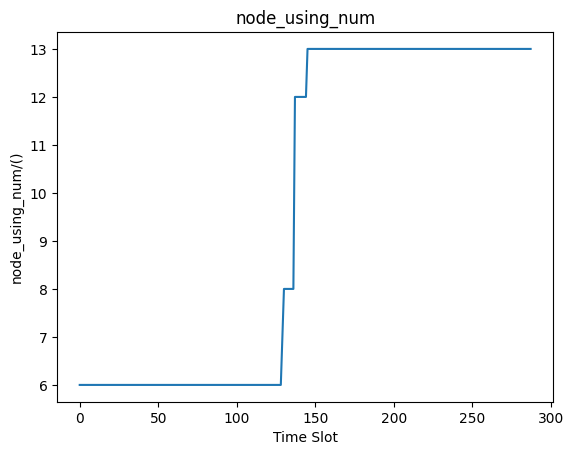

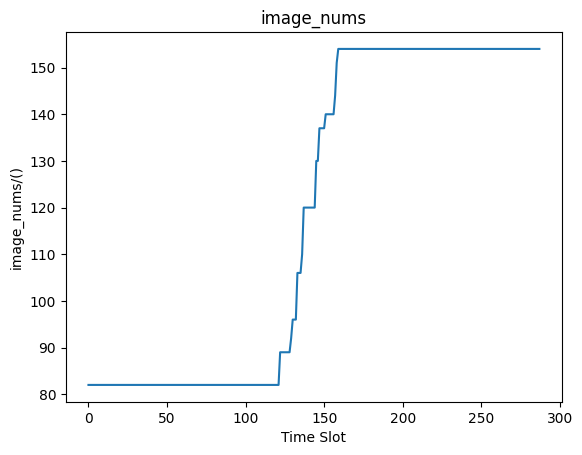

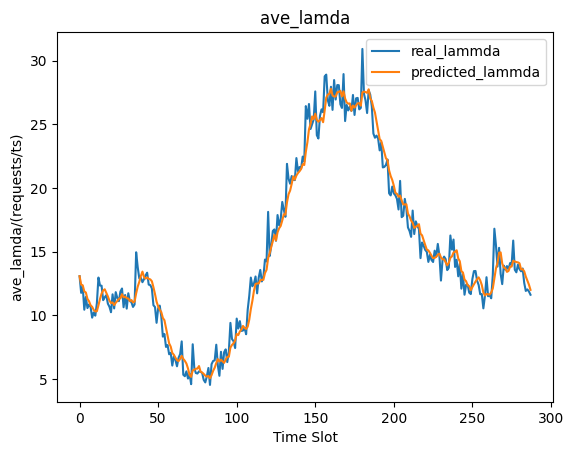

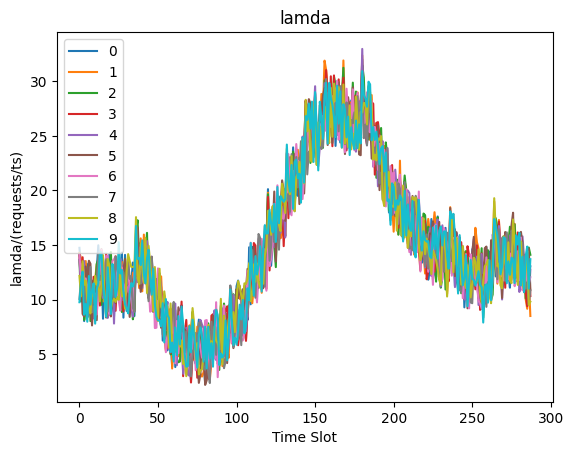

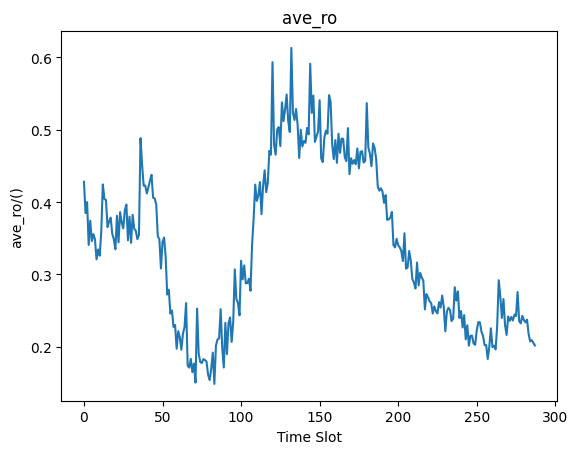

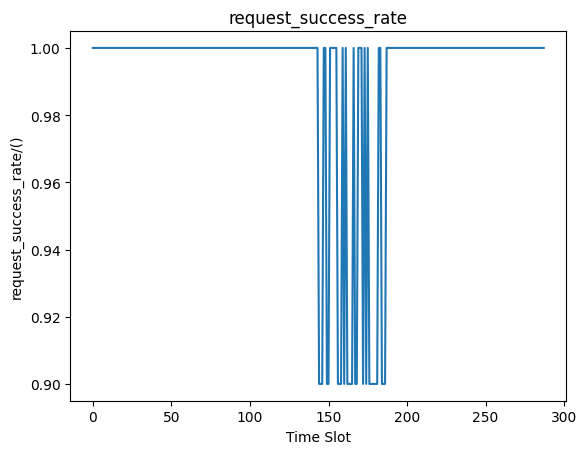

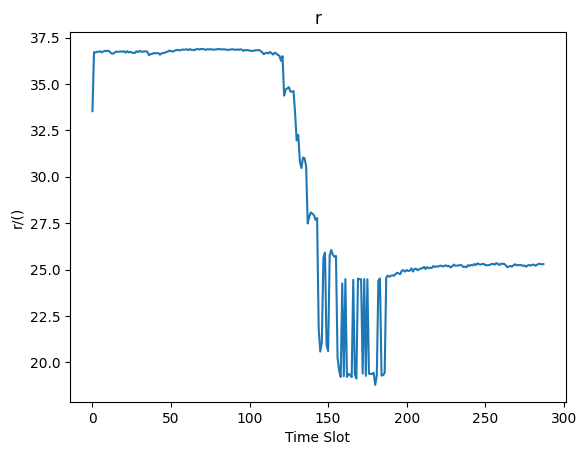

In [4]:
env_config = config.EnvConfig()
predicter = Predicter.SMAPredictor(env_config.ms_nums, env_config.predicter_window_size)
env = environment.DataCenterEnvironment(0, env_config)
# agent = ConstantScaling.ConstantScalingAgent(env)
# agent = RandomScaling.RandomScalingAgent(env)
agent = GDCScaling.GDCScalingAgent(env)
logger = loghelper.LogHelper()
train_and_test_helper = TrainAndTestHelper(env, agent, logger)
train_and_test_helper.test()